In [119]:
from bauer.utils.data import load_garcia2022
from bauer.models import RiskModel, RiskLapseModel
import numpy as np
import pandas as pd
import seaborn as sns
from bauer.utils.plotting import plot_ppc

In [120]:
df = load_garcia2022(task='risk')

In [121]:
df = df.xs('non-symbolic', 0, 'format')

In [122]:
model = RiskLapseModel(data=df, prior_estimate='klw', fit_seperate_evidence_sd=False)

In [123]:
model.build_estimation_model()

In [124]:
idata = model.sample(1000, 1000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [evidence_sd_mu_untransformed, evidence_sd_sd, evidence_sd_offset, prior_std_mu_untransformed, prior_std_sd, prior_std_offset, p_lapse_mu_untransformed, p_lapse_sd, p_lapse_offset]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 391 seconds.
There were 1 divergences after tuning. Increase `target_accept` or reparameterize.


        evidence_sd          
            hdi_low  hdi_high
subject                      
1          0.096019  0.201830
2          0.096332  0.193179
3          0.212308  0.413169
4          0.154254  0.247327
5          0.171357  0.383304
...             ...       ...
60         0.127550  0.195921
61         0.181170  0.297829
62         0.080059  0.174269
63         0.120495  0.220712
64         0.111684  0.237613

[64 rows x 2 columns]


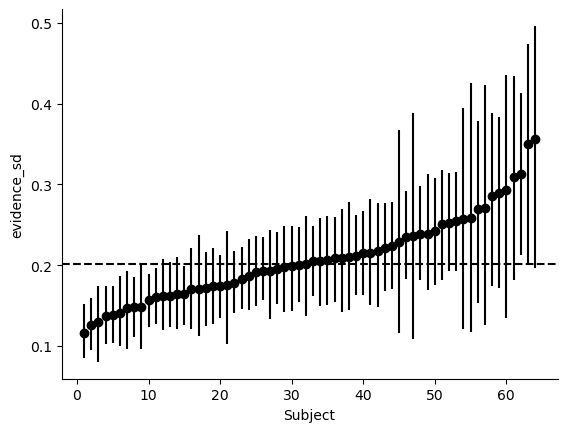

In [128]:
from bauer.utils.plotting import plot_subjectwise_parameters
plot_subjectwise_parameters(idata, parameter='evidence_sd')

          p_lapse          
          hdi_low  hdi_high
subject                    
1        0.000002  0.102666
2        0.000018  0.069063
3        0.000004  0.085074
4        0.000007  0.069959
5        0.000015  0.280668
...           ...       ...
60       0.000014  0.037388
61       0.000003  0.048286
62       0.000001  0.030730
63       0.000011  0.084042
64       0.000008  0.022260

[64 rows x 2 columns]


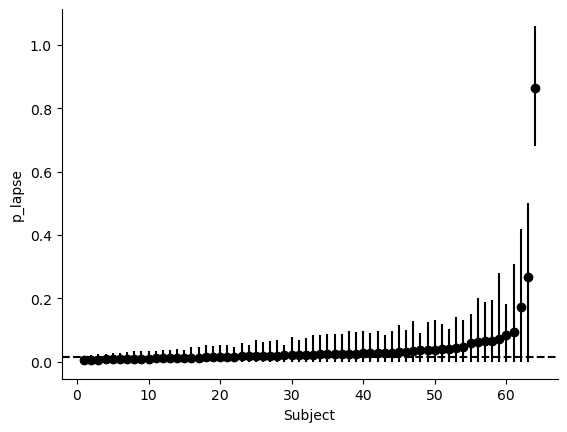

In [129]:
plot_subjectwise_parameters(idata, parameter='p_lapse')

              rnp          
          hdi_low  hdi_high
subject                    
1        0.254354  0.323223
2        0.348803  0.367294
3        0.025507  0.089290
4        0.254546  0.325285
5        0.325540  0.364696
...           ...       ...
60       0.169914  0.214061
61       0.103498  0.154364
62       0.349451  0.367331
63       0.176075  0.225416
64       0.048157  0.100299

[64 rows x 2 columns]


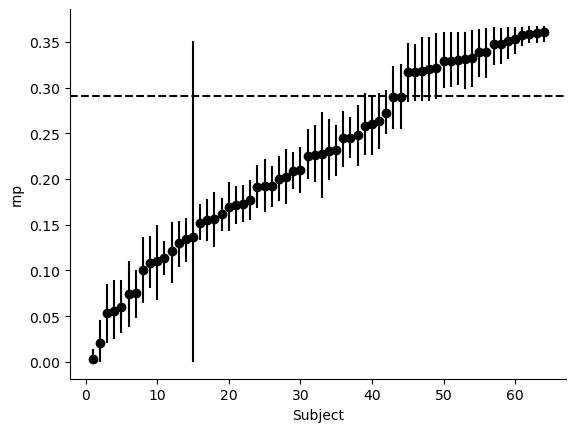

In [140]:
def get_rnp(evidence_sd, prior_std):
    return np.exp(-(1./ (prior_std**2 / (evidence_sd**2 + prior_std**2))))

idata.posterior['rnp'] = get_rnp(idata.posterior['evidence_sd'], idata.posterior['prior_std'])
idata.posterior['rnp_mu'] = get_rnp(idata.posterior['evidence_sd_mu'], idata.posterior['prior_std_mu'])

plot_subjectwise_parameters(idata, parameter='rnp')

In [136]:
idata.posterior['rnp'] = np.exp(-(idata.posterior['evidence_sd'] + idata.posterior['prior_std']) / (idata.posterior['prior_std'] ))
idata.posterior['rnp_mu'] = np.exp(-(idata.posterior['evidence_sd_mu'] + idata.posterior['prior_std_mu']) / (idata.posterior['prior_std_mu'] ))

In [143]:
ppc = model.ppc(df, idata)

Sampling: [ll_bernoulli]


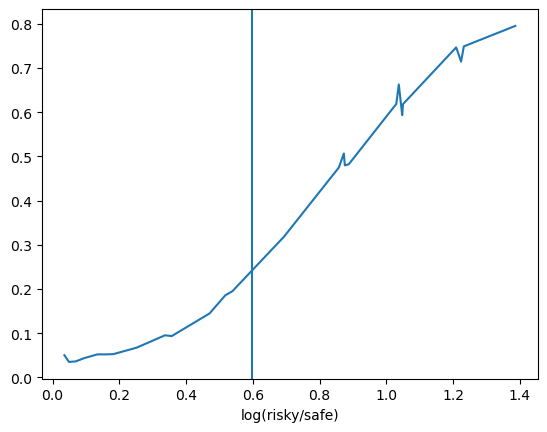

In [148]:
import matplotlib.pyplot as plt
ppc.groupby('log(risky/safe)').mean().mean(1).plot()

plt.axvline(np.log(1/.55))

In [153]:
from bauer.utils.plotting import plot_ppc

In [157]:
df['log(n2/n1)'] = np.log(df['n2'] / df['n1'])

/Users/gdehol/git/bauer/bauer/utils/bayes.py:38: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  hdi = pd.DataFrame(az.hdi(ppc.T.values), index=ppc.index,
/Users/gdehol/git/bauer/bauer/utils/plotting.py:55: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  p = df.groupby(groupby).mean()[['choice']]


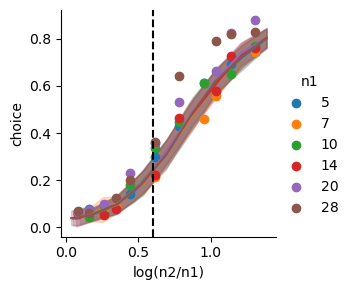

In [162]:
plot_ppc(df, ppc, var_name='ll_bernoulli', plot_type=1, level='group')

plt.axvline(np.log(1./0.55), c='k', ls='--')